<p>
    <a href="https://umt.edu.al/en/anxhelo-shehu/" target="_blank">
    <img src="https://umt.edu.al/wp-content/uploads/2022/10/Anxhelo-Shehu-min-2-300x300.jpg" width="150" alt="UMT Logo">
    </a>
</p>
<p>
    <a href="https://umt.edu.al/" target="_blank">
    <img src="https://umt.edu.al/wp-content/uploads/2024/11/Universiteti-Metropolitan-Tirana.webp" width="200" alt="UMT Logo">
    </a>
</p>

## Cfare do te mesojme? 

* Image thresholding!
* Komponentet e lidhur

### Rajono i Vetem begraund-ROI (nje numer/ simbol)

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [3]:
numri_me_ngjyre = cv2.imread("numri.jpg")
numri = cv2.imread("numri.jpg", cv2.IMREAD_GRAYSCALE)

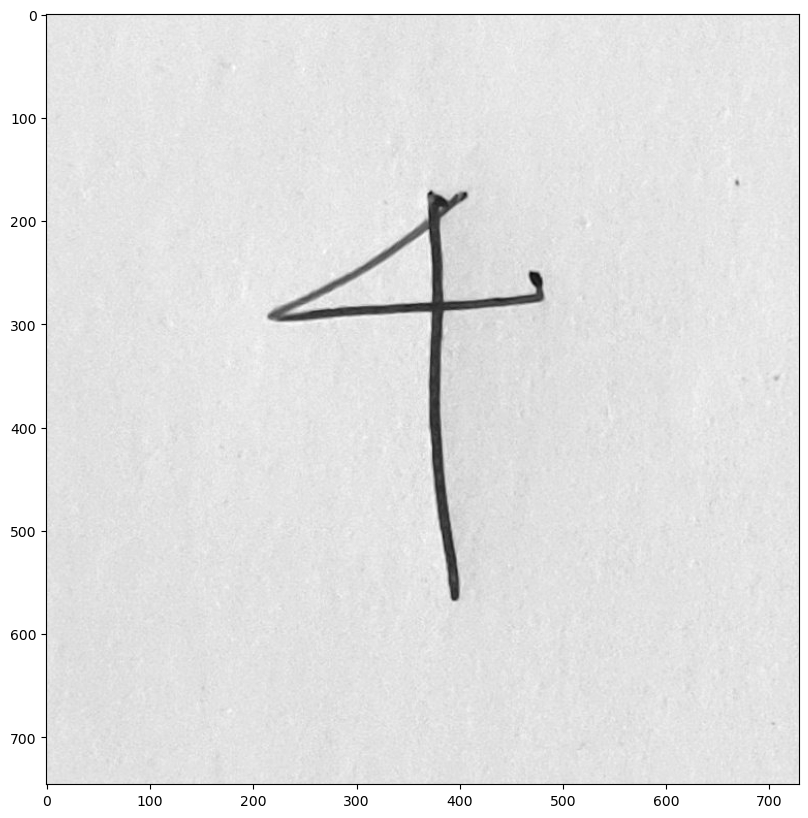

In [4]:
plt.figure(figsize=(10,10))
plt.imshow(numri, cmap="gray")
plt.show()

In [5]:
numri

array([[154, 157, 158, ..., 153, 153, 153],
       [154, 156, 157, ..., 155, 154, 153],
       [153, 155, 154, ..., 155, 155, 154],
       ...,
       [151, 153, 153, ..., 157, 158, 156],
       [153, 152, 152, ..., 158, 157, 156],
       [153, 152, 152, ..., 157, 156, 154]], dtype=uint8)

In [6]:
numri.shape

(746, 729)

In [7]:
def threshold(img, val):
    return 255*(img < val).astype(img.dtype)

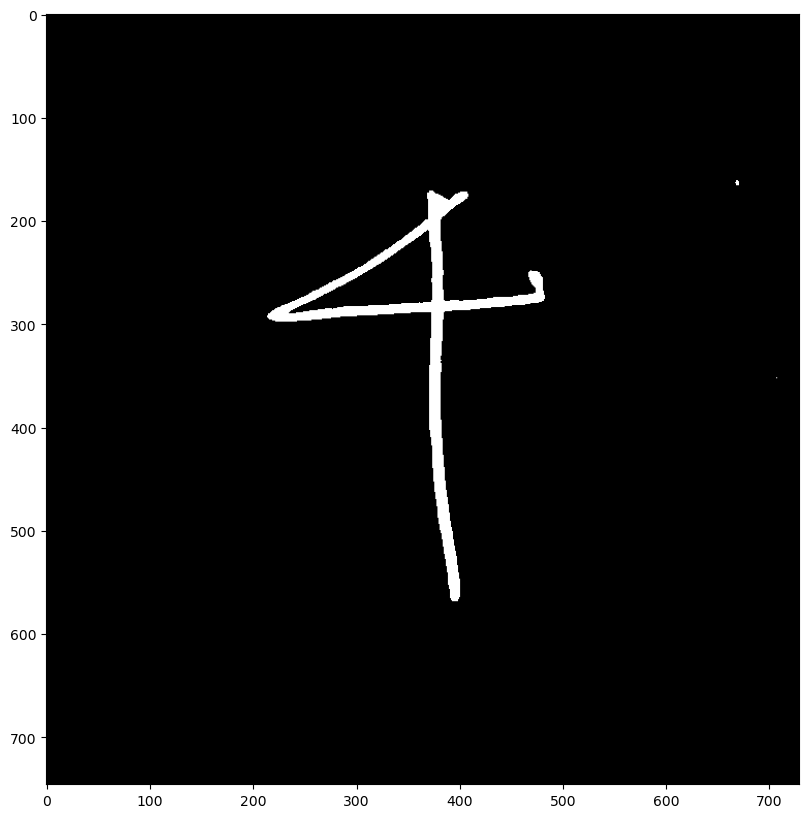

In [8]:
plt.figure(figsize=(10,10))

thresh = threshold(numri, 120)
plt.imshow(thresh, cmap="gray")
plt.show()

In [9]:
# kufizimi i simbolit brenda nje drrejtkendeshi

def get_bounding_box(img):

    points = []
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if img[i, j] == 255:
                points.append((i, j))
    
    points = np.array(points)
    x_min, y_min, x_max, y_max = points[:, 1].min(), points[:, 0].min(), points[:, 1].max(), points[:, 0].max()

    return x_min, y_min, x_max, y_max


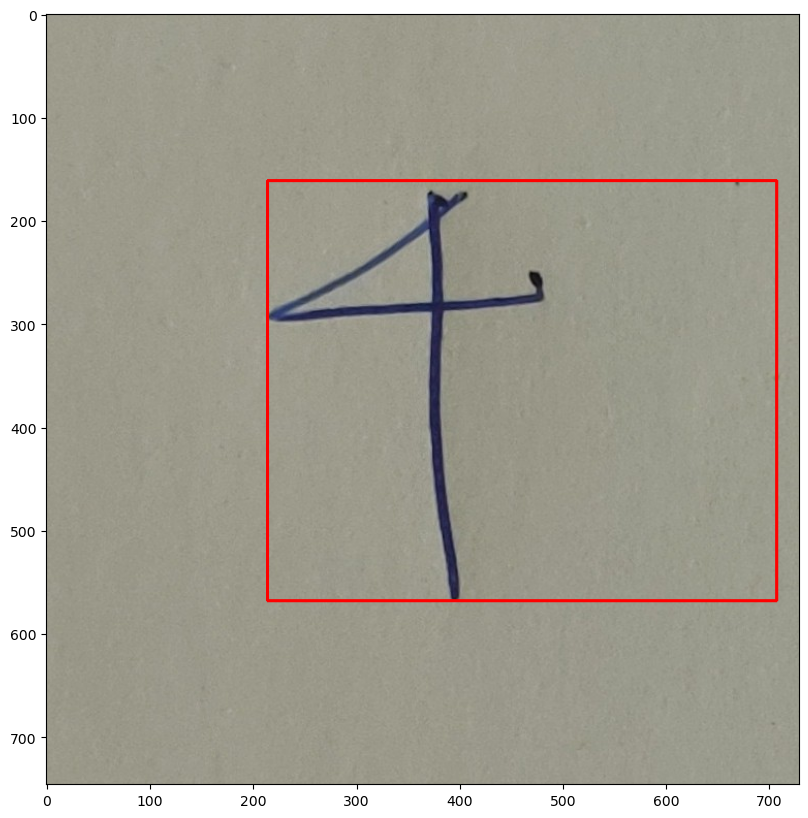

In [10]:
draw_img = numri_me_ngjyre.copy()

x_min, y_min, x_max, y_max = get_bounding_box(thresh)
cv2.rectangle(draw_img, (x_min, y_min), (x_max, y_max), (0, 0, 255), 2)

plt.figure(figsize=(10,10))
plt.imshow(draw_img[...,[2,1,0]])
plt.show()

## Përshkrimi i Operacioneve të Koduara

Ky kod përmban dy funksione kryesore për analizën e komponentëve të lidhur në një imazh:

1. **Funksioni `check_neighbour`**: Ky funksion kontrollon fqinjët e një pozite të caktuar në një imazh duke përdorur një model të fqinjesisë. Funksioni mund të punojë me:
   - **Fqinjesi 4**: kontrollon katër fqinje (lart, poshtë, majtas, djathtas).
   - **Fqinjesi 8**: kontrollon tetë fqinje, përfshirë diagonalet.

   Funksioni kthen pozitat e fqinjeve të vlefshme që janë brenda kufijve të imazhit.

2. **Funksioni `connected_components`**: Ky funksion realizon kërkimin e komponentëve të lidhur duke përdorur një metodë të zgjeruar dhe një radhë (queue). Ai viziton pikselët që përputhen me vlera të dhëna dhe etiketohen me një etiketë të veçantë. Kjo mundëson identifikimin e grupeve të komponentëve të lidhur në imazh.


In [11]:
# Definojmë një funksion për kontrollin e fqinjëve të rajonit
def kontrollo_fqinjet(img, pozita, fqinjesia):
    fqinjet = []
    i, j = pozita
    r, c = img.shape
    if fqinjesia == 4:
        for x, y in [(i, j - 1), (i - 1, j), (i, j + 1), (i + 1, j)]:
            if x >= 0 and y >= 0 and x < r and y < c:
                fqinjet.append((x, y))
    elif fqinjesia == 8:
        for x, y in [
            (i, j - 1),
            (i - 1, j - 1),
            (i - 1, j),
            (i - 1, j + 1),
            (i, j + 1),
            (i + 1, j + 1),
            (i + 1, j),
            (i + 1, j - 1),
        ]:
            if x >= 0 and y >= 0 and x < r and y < c:
                fqinjet.append((x, y))
    return fqinjet

# Komponentët e lidhur
def komponentet_e_lidhura(img, V, fqinjesia):
    etiketimi = 1
    flamuri = np.zeros(img.shape).astype("bool")
    komponent = np.zeros(img.shape, dtype=img.dtype)
    radhë = []
    grupe = []
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if (img[i][j] in V) and (not flamuri[i][j]):
                komponent[i][j] = etiketimi
                grupe.append([(i, j)])
                flamuri[i][j] = True
                radhë.insert(0, (i, j))
                while len(radhë) > 0:
                    i, j = radhë.pop()
                    fqinjet = kontrollo_fqinjet(img, (i, j), fqinjesia)
                    for fqinji in fqinjet:
                        i, j = fqinji
                        if (img[i][j] in V) and (not flamuri[i][j]):
                            komponent[i][j] = etiketimi
                            grupe[-1].append((i,j))
                            flamuri[i][j] = True
                            radhë.insert(0, (i, j))
                etiketimi += 1
    return komponent, grupe


In [12]:
components, groups = komponentet_e_lidhura(thresh, [255], 8)

Ky kod realizon vizatimin e drejtkëndëshave rreth komponentëve të lidhur në një imazh.
Për çdo grup të pikselave të lidhur, ai gjen kufijtë minimalë dhe maksimalë, vizaton një drejtkëndësh rreth tij dhe e shfaq imazhin e përpunuar. Përdoret për të vizualizuar dhe verifikuar rezultatet e detektimit të grupeve të pikselave.

667 161 670 165


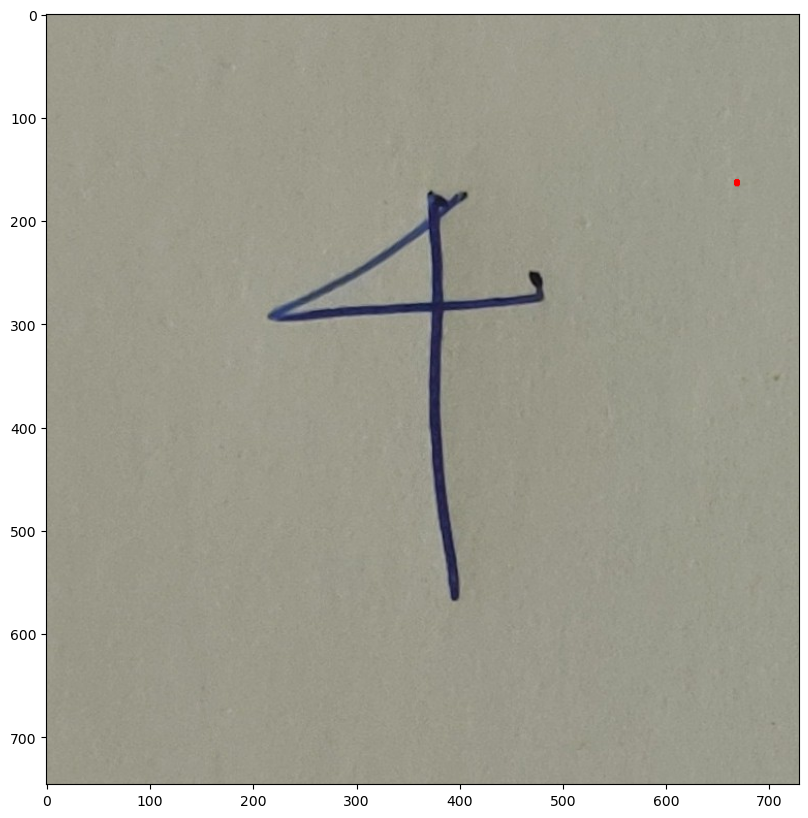

214 171 482 568


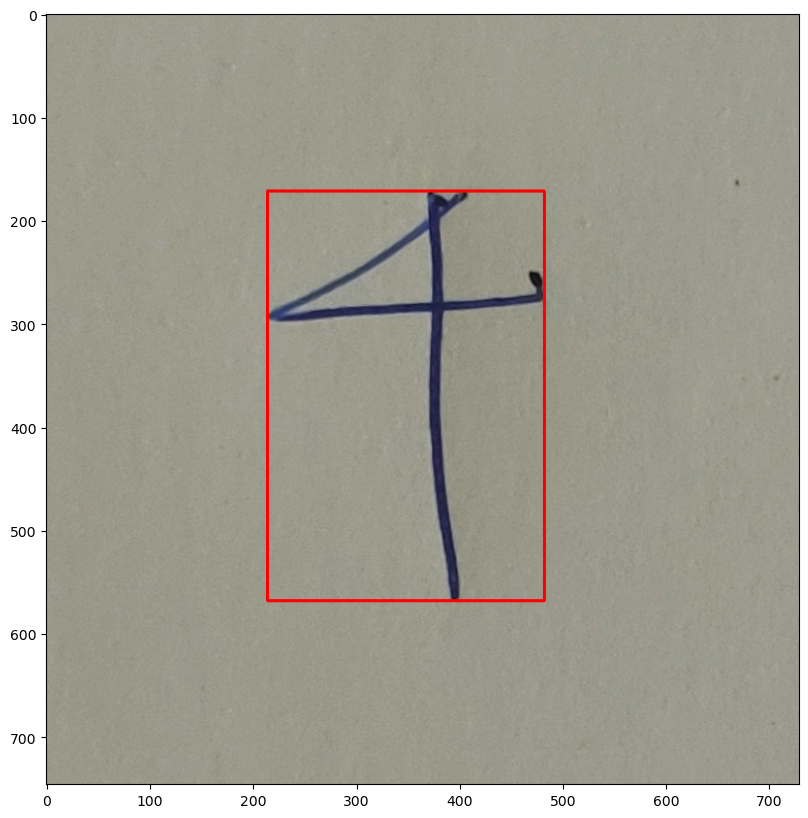

707 352 707 352


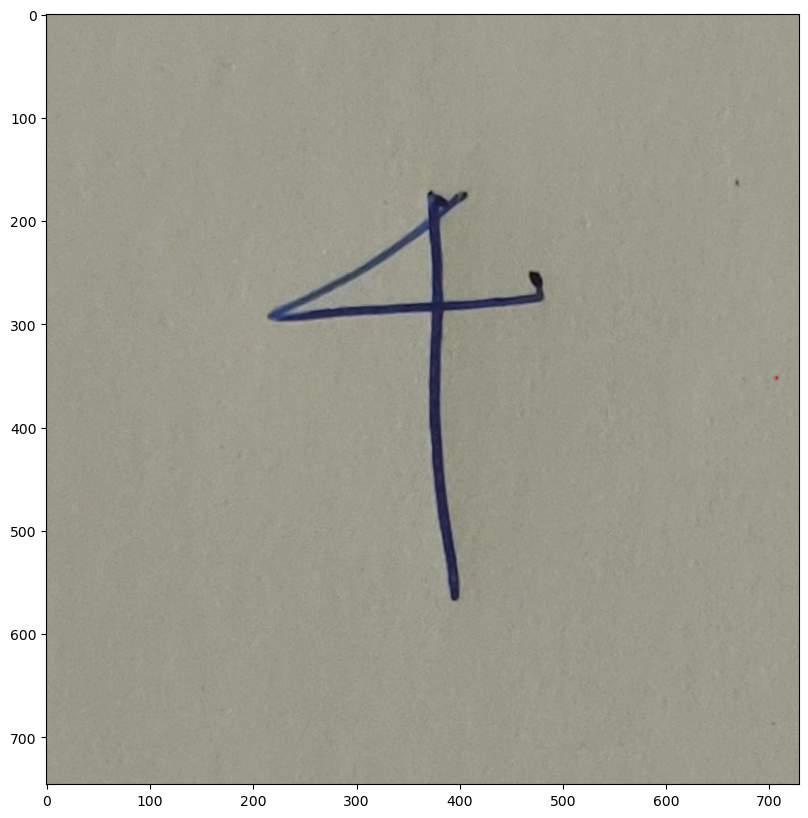

In [13]:
for group in groups:
    draw_img = numri_me_ngjyre.copy()

    group = np.array(group)
    x_min, y_min, x_max, y_max = group[:, 1].min(), group[:, 0].min(), group[:, 1].max(), group[:, 0].max()
    cv2.rectangle(draw_img, (x_min, y_min), (x_max, y_max), (0, 0, 255), 2)
    print(x_min, y_min, x_max, y_max)


    plt.figure(figsize=(10,10))
    plt.imshow(draw_img[...,[2,1,0]])
    plt.show()

In [14]:
numri_me_ngjyre[170:568, 214:482]

array([[[137, 152, 154],
        [140, 155, 157],
        [141, 156, 158],
        ...,
        [139, 155, 154],
        [141, 155, 154],
        [142, 156, 155]],

       [[138, 153, 155],
        [140, 155, 157],
        [139, 154, 156],
        ...,
        [141, 157, 156],
        [142, 156, 155],
        [142, 156, 155]],

       [[139, 154, 156],
        [141, 156, 158],
        [137, 152, 154],
        ...,
        [141, 157, 156],
        [142, 156, 155],
        [142, 156, 155]],

       ...,

       [[140, 155, 157],
        [139, 154, 156],
        [138, 153, 155],
        ...,
        [139, 152, 154],
        [141, 154, 156],
        [140, 153, 155]],

       [[138, 153, 155],
        [138, 153, 155],
        [138, 153, 155],
        ...,
        [140, 153, 155],
        [140, 153, 155],
        [139, 152, 154]],

       [[138, 153, 155],
        [139, 154, 156],
        [143, 158, 160],
        ...,
        [142, 155, 157],
        [141, 154, 156],
        [139, 152, 154]]

### Disa Simbole

In [15]:
numri_me_ngjyre = cv2.imread("numra.jpg")
numri = cv2.imread("numra.jpg", cv2.IMREAD_GRAYSCALE)

In [16]:
numri.shape

(2112, 2818)

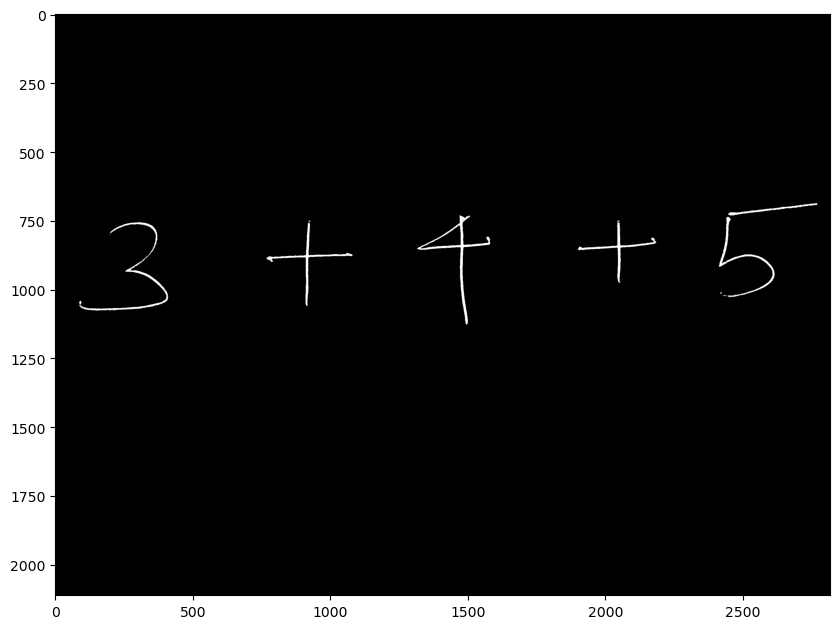

In [17]:
plt.figure(figsize=(10,10))

thresh = threshold(numri, 80)
plt.imshow(thresh, cmap="gray")
plt.show()

In [18]:
components, groups = komponentet_e_lidhura(thresh, [255], 8)

In [19]:
len(groups)

12

707 352 707 352


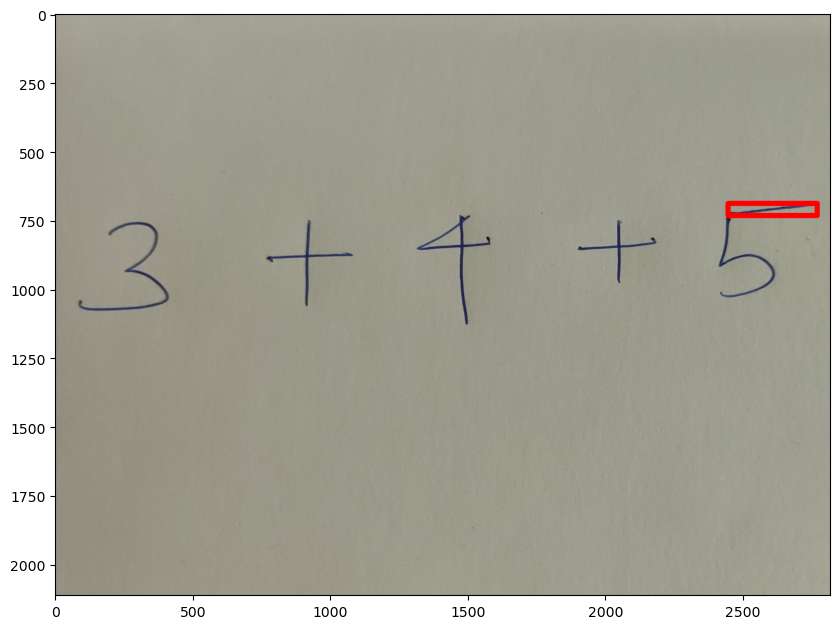

2447 688 2771 732


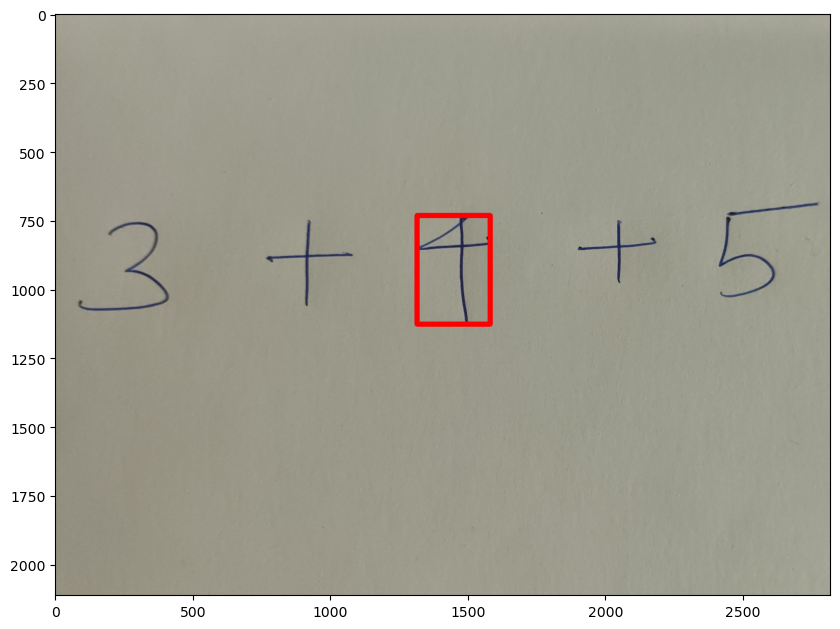

1316 732 1582 1127


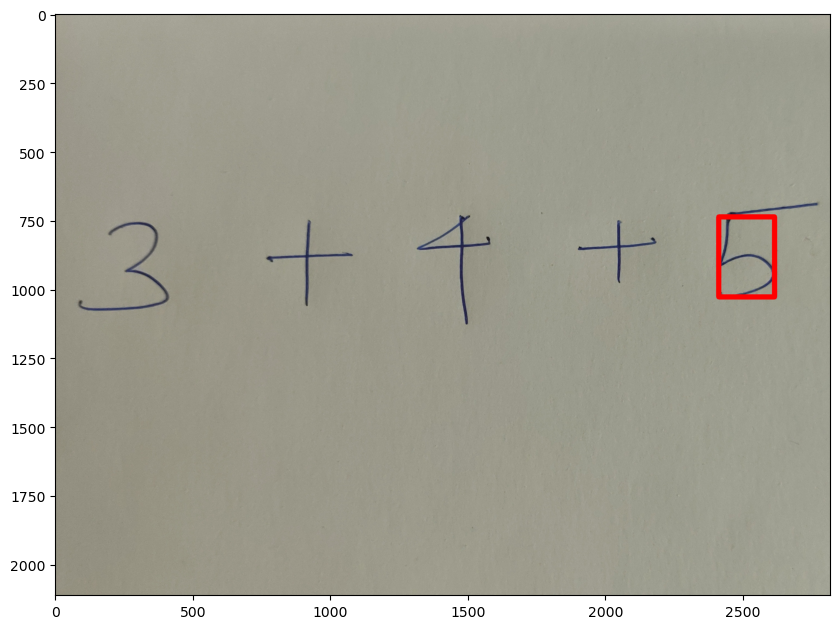

2413 737 2616 1028


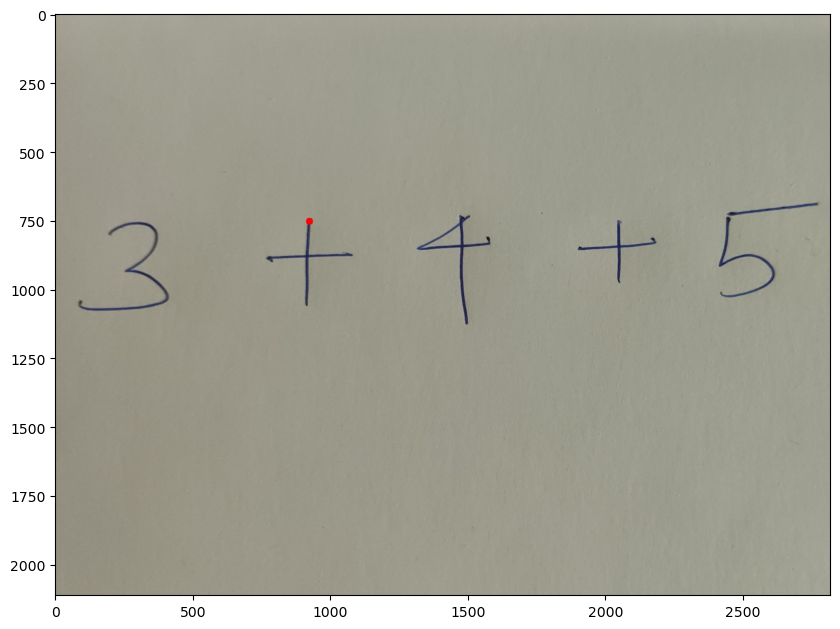

922 750 928 756


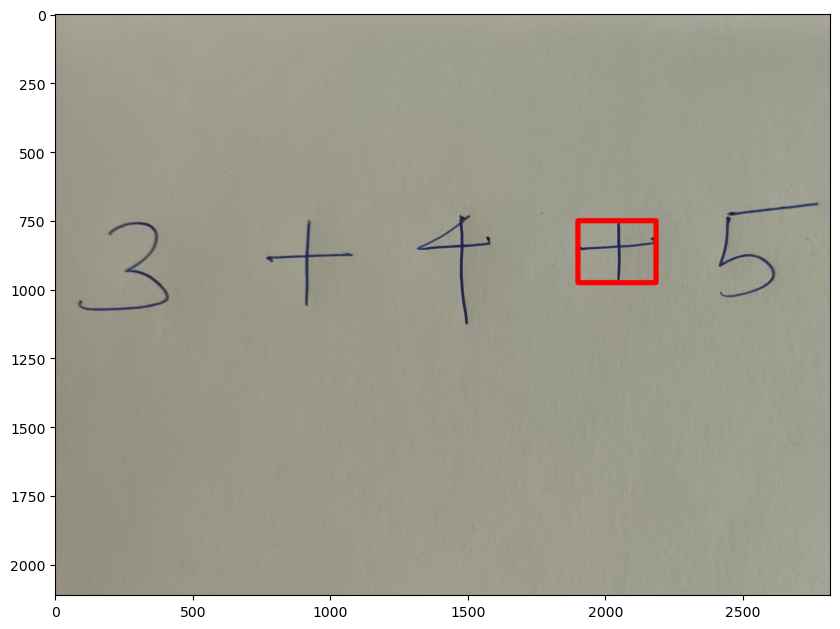

1901 751 2185 976


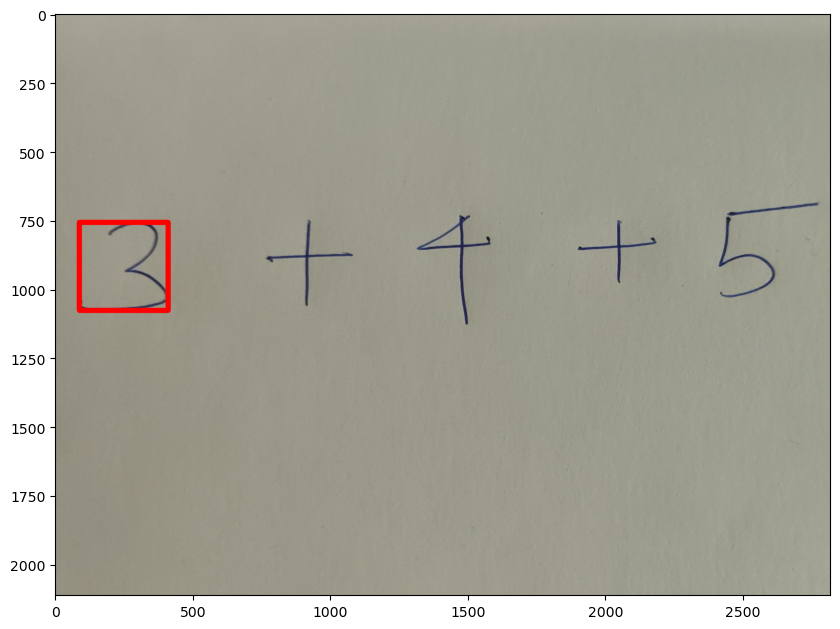

88 757 411 1077


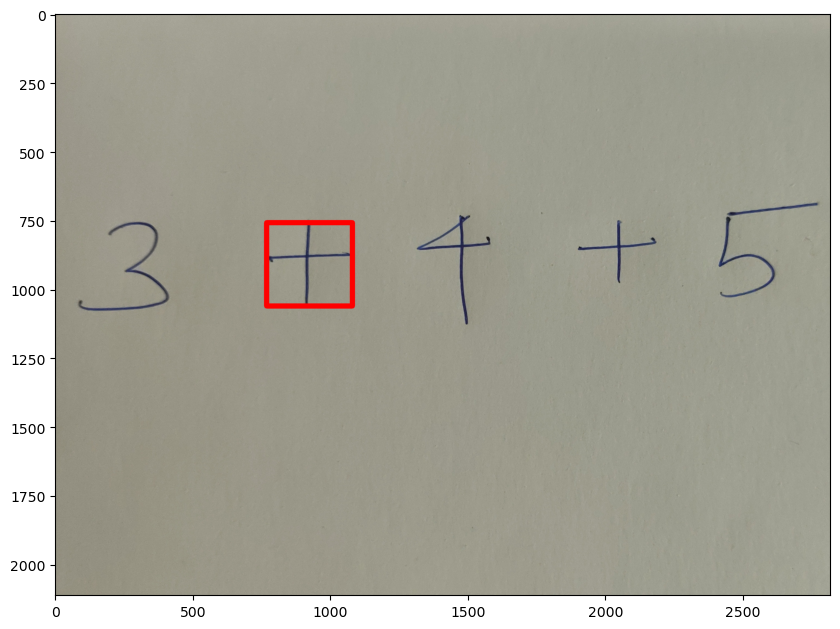

769 758 1081 1061


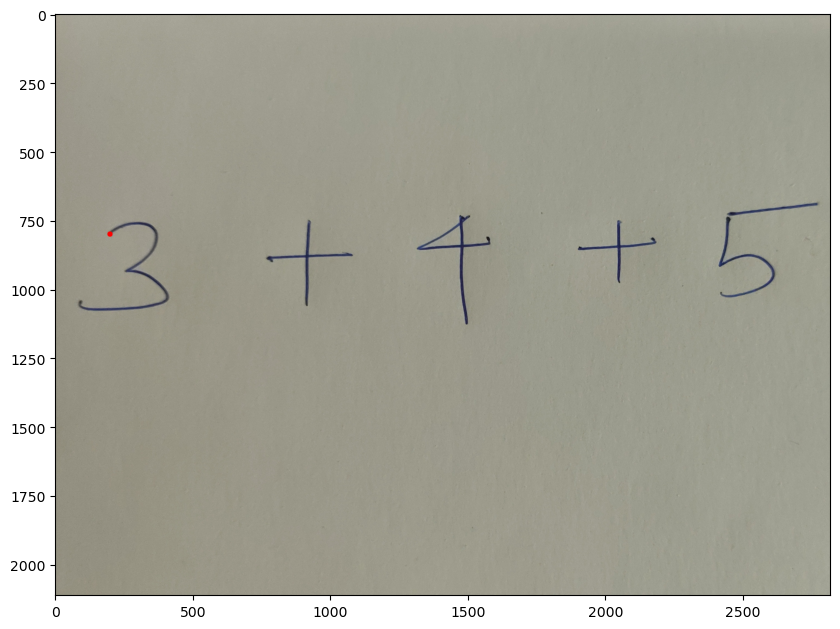

199 799 200 800


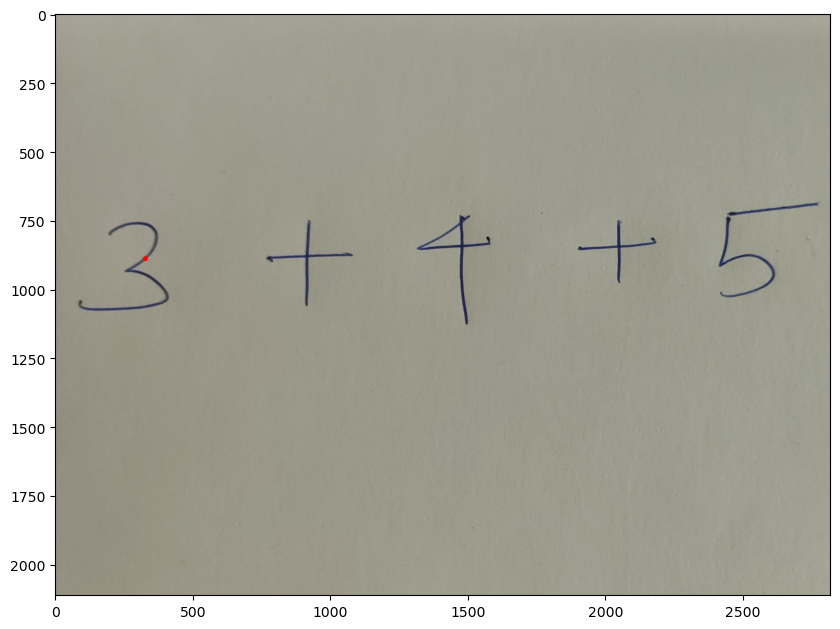

328 889 328 889


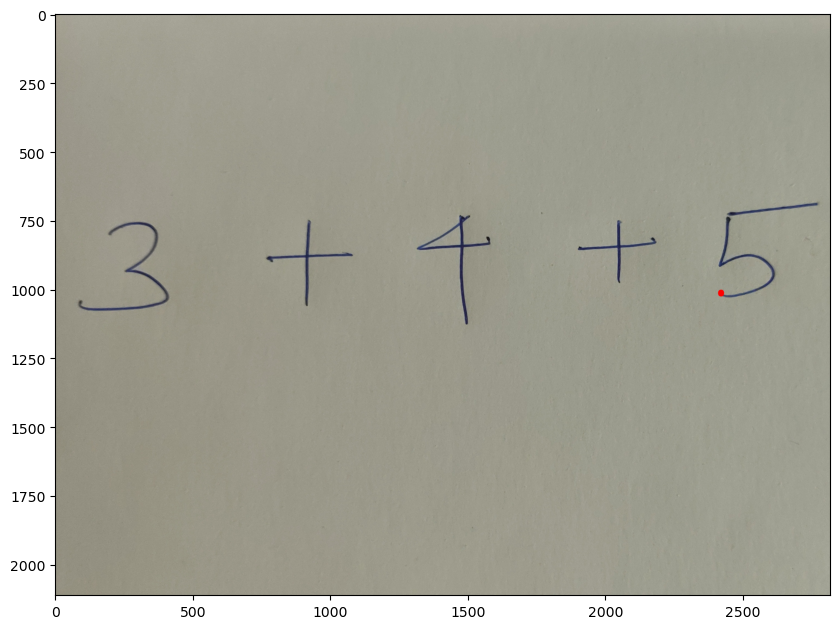

2420 1011 2423 1017


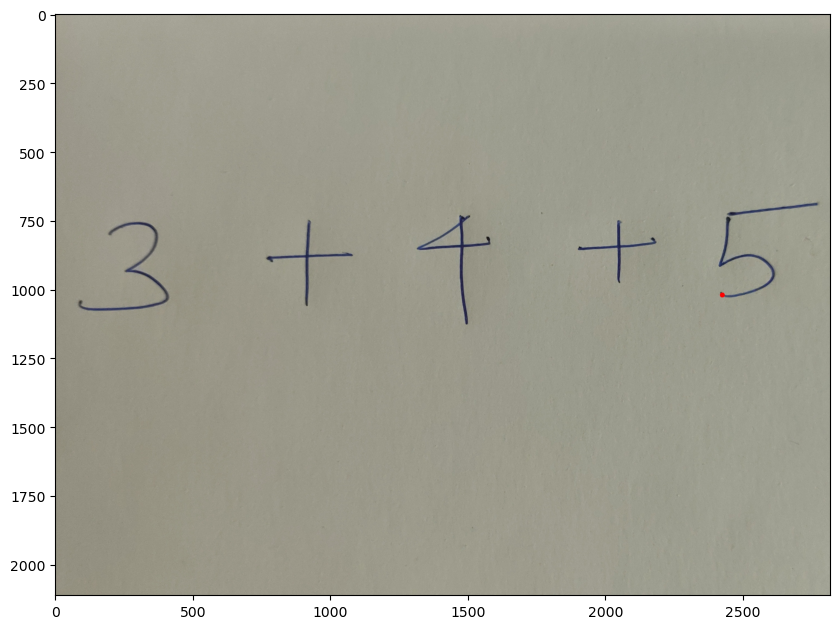

2426 1021 2426 1021


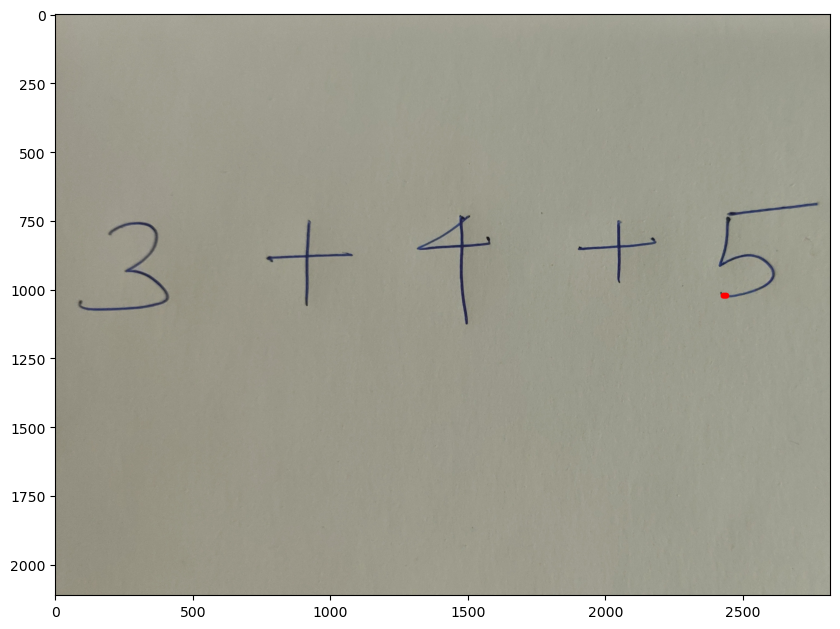

In [20]:
for group in groups:
    draw_img = numri_me_ngjyre.copy()

    group = np.array(group)
    print(x_min, y_min, x_max, y_max)
    x_min, y_min, x_max, y_max = group[:, 1].min(), group[:, 0].min(), group[:, 1].max(), group[:, 0].max()
    cv2.rectangle(draw_img, (x_min, y_min), (x_max, y_max), (0, 0, 255), 18)


    plt.figure(figsize=(10,10))
    plt.imshow(draw_img[...,[2,1,0]])
    plt.show()

#### Zvogelojme dimensionet edhe rrisim kontrastin mbi imazh per te kapercyer pengesat

In [21]:
numri_me_ngjyre.shape

(2112, 2818, 3)

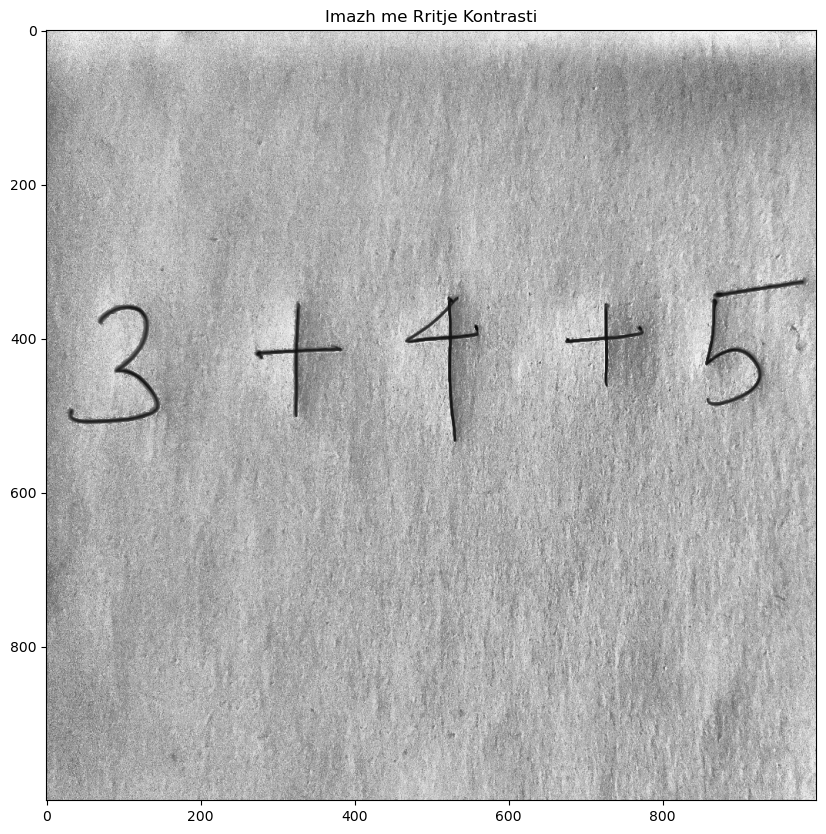

In [22]:

# Zvogëlojmë dimensionet e imazhit (p.sh. në 224x224)
imazhi_i_zvogluar = cv2.resize(numri_me_ngjyre, (1000, 1000))

# Përdorim CLAHE për rritjen e kontrastit
# CLAHE (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=8.0, tileGridSize=(8, 8))
# Shndërrojmë imazhin në gri për CLAHE
imazhi_gri = cv2.cvtColor(imazhi_i_zvogluar, cv2.COLOR_BGR2GRAY)
imazhi_me_ritje_contrasti = clahe.apply(imazhi_gri)

# Shfaqim imazhin e përpunuar
plt.figure(figsize=(10,10))
plt.imshow(imazhi_me_ritje_contrasti, cmap='gray')
plt.title('Imazh me Rritje Kontrasti')
plt.show()


In [23]:
# ose metoda te tjers

In [24]:
# aplikojme tresholding